In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('file_123.xlsx')

In [3]:
df.head()

,Event,Voltage Min (V),Voltage Max (V),Current (A),Remarks
0,Normal Running,241,245,0.1,Device running normally
1,Normal Running,241,245,0.1,Device running normally
2,Normal Running,241,245,0.1,Device running normally
3,Normal Running,241,245,0.1,Device running normally
4,Normal Running,241,243,0.1,Device running normally


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Event            279 non-null    object 
 1   Voltage Min (V)  279 non-null    int64  
 2   Voltage Max (V)  279 non-null    int64  
 3   Current (A)      279 non-null    float64
 4   Remarks          279 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.0+ KB


In [5]:
df.describe()

,Voltage Min (V),Voltage Max (V),Current (A)
count,279.000000,279.000000,279.000000
mean,242.283154,244.888889,0.116129
std,0.769544,0.687911,0.011351
min,241.000000,243.000000,0.100000
25%,242.000000,245.000000,0.110000
50%,242.000000,245.000000,0.120000
75%,243.000000,245.000000,0.130000
max,244.000000,246.000000,0.130000


In [6]:
normal = df[df['Event'] == 'Normal Running']
normal

,Event,Voltage Min (V),Voltage Max (V),Current (A),Remarks
0,Normal Running,241,245,0.1,Device running normally
1,Normal Running,241,245,0.1,Device running normally
2,Normal Running,241,245,0.1,Device running normally
3,Normal Running,241,245,0.1,Device running normally
4,Normal Running,241,243,0.1,Device running normally
5,Normal Running,241,243,0.1,Device running normally
6,Normal Running,241,243,0.1,Device running normally
7,Normal Running,241,243,0.1,Device running normally
8,Normal Running,241,243,0.1,Device running normally
9,Normal Running,241,243,0.1,Device running normally


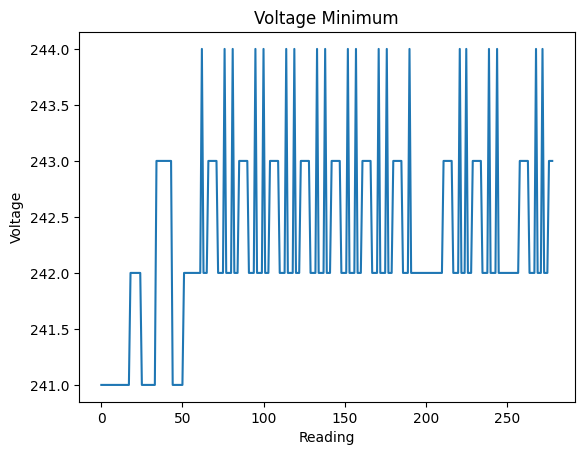

In [7]:
import matplotlib.pyplot as plt

plt.plot(df['Voltage Min (V)'])
plt.title("Voltage Minimum")
plt.xlabel("Reading")
plt.ylabel("Voltage")
plt.show()

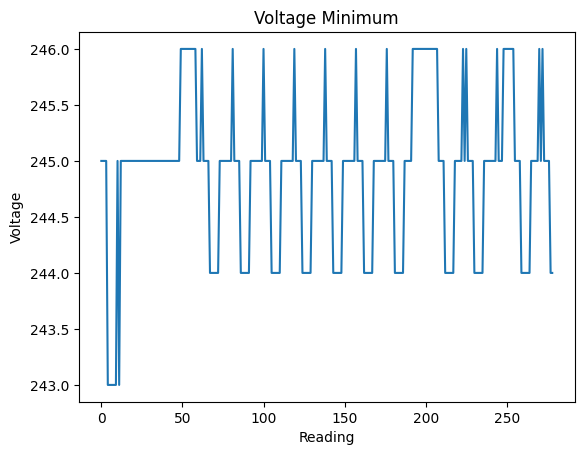

In [8]:
plt.plot(df['Voltage Max (V)'])
plt.title("Voltage Minimum")
plt.xlabel("Reading")
plt.ylabel("Voltage")
plt.show()

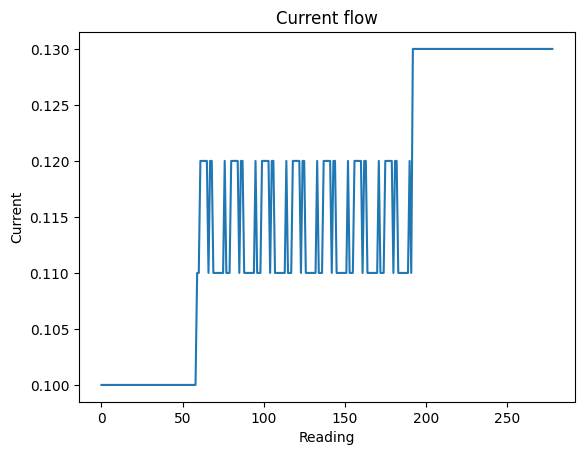

In [9]:
plt.plot(df['Current (A)'])
plt.title("Current flow")
plt.xlabel("Reading")
plt.ylabel("Current")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define threshold for high current (e.g., based on mean or specific domain knowledge)
# From df.describe(), max current is 0.13, mean is ~0.116
threshold_value = 0.12 

# Create target variable based on threshold
df['Current_Class'] = np.where(df['Current (A)'] >= threshold_value, 'High', 'Normal')

print("Class distribution:")
print(df['Current_Class'].value_counts())

# Features and target
X = df[['Voltage Min (V)', 'Voltage Max (V)']]
y = df['Current_Class']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
\n